In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import tensorflow as tf
import numpy as np

In [ ]:
inputs = np.random.random((32, 20, 8))

In [ ]:
gru = tf.keras.layers.GRU(4, return_sequences=True)

In [ ]:
gru(inputs)

<tf.Tensor: shape=(32, 20, 4), dtype=float32, numpy=
array([[[ 3.28580558e-01,  1.09183438e-01,  1.05240256e-01,
         -3.49780411e-01],
        [ 2.53627479e-01,  3.89465332e-01,  1.61488906e-01,
         -4.81293797e-01],
        [ 2.66622722e-01,  5.34081221e-01,  1.01694137e-01,
         -6.31292582e-01],
        ...,
        [-3.11172307e-02,  3.85285079e-01,  1.98629081e-01,
         -4.18465376e-01],
        [-9.33969989e-02,  4.25126255e-01,  6.75589293e-02,
         -3.94306660e-01],
        [-1.35185540e-01,  4.56002980e-01,  7.01020807e-02,
         -2.67242014e-01]],

       [[ 4.56201757e-04,  2.64930218e-01, -5.61328940e-02,
         -3.30503166e-01],
        [ 3.46254289e-01,  5.03903687e-01, -1.18730500e-01,
         -4.99806166e-01],
        [ 3.42384428e-01,  4.98802185e-01, -5.28351031e-02,
         -3.35305423e-01],
        ...,
        [ 2.55231619e-01,  6.55248046e-01,  4.11223546e-02,
         -2.44102120e-01],
        [ 1.77994817e-02,  5.19315004e-01,  2.475

In [ ]:
text = "What do you call a person when is shakes a pear? Shakespeare's plays are as popular as they are because he was perhaps the greatest writer who has ever lived. It's partly because he was writing plays which go on being performed and therefore which can be brought freshly to life for each generation by actors of the present."


In [ ]:
words = text.split(" ")
print(len(words))

59


In [ ]:
vocab = sorted(set(words))
print(len(vocab))

50


In [ ]:
word_map = {}
for i, word in enumerate(vocab):
    word_map[word] = i

In [ ]:
x_data = [word_map[t] for t in words]

In [ ]:
import tensorflow as tf

In [ ]:
conv1 = tf.keras.layers.Conv1D(1, 3, activation='linear')

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(None, 1)),
    tf.keras.layers.Conv1D(1, 3, activation='linear')
])
model.compile(loss='mse', optimizer='adam')


In [ ]:
model(tf.expand_dims(tf.expand_dims(x_data, -1), 0))

<tf.Tensor: shape=(1, 57, 1), dtype=float32, numpy=
array([[[-12.620707 ],
        [-36.219276 ],
        [-22.833181 ],
        [ -7.4656568],
        [-24.735725 ],
        [-39.243973 ],
        [-30.773573 ],
        [-31.660526 ],
        [-14.668714 ],
        [-20.636257 ],
        [-11.541869 ],
        [-22.845009 ],
        [-14.468815 ],
        [ -8.050217 ],
        [-25.297022 ],
        [-17.13244  ],
        [-28.423857 ],
        [-16.336254 ],
        [ -8.709414 ],
        [-20.094522 ],
        [-36.07395  ],
        [-35.614853 ],
        [-35.618923 ],
        [-27.854618 ],
        [-38.69066  ],
        [-44.238262 ],
        [-29.020039 ],
        [-18.949032 ],
        [-22.162384 ],
        [ -9.474363 ],
        [-19.525925 ],
        [-15.771213 ],
        [-20.094522 ],
        [-36.83887  ],
        [-44.94436  ],
        [-38.66316  ],
        [-39.969807 ],
        [-28.0666   ],
        [-25.12043  ],
        [-16.520494 ],
        [-23.535494 ],
     

In [ ]:
import numpy as np
import tensorflow as tf

In [ ]:
x = np.random.random((32, 20, 8))
y = np.array(list(range(32)))

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices((x, y)).batch(1)

In [ ]:
# dataset = dataset.prefetch(tf.data.AUTOTUNE).batch(4)

In [ ]:
train_dataset = dataset.take(20)
val_dataset = dataset.skip(20).take(5)
test_dataset = dataset.skip(25)

In [ ]:
# model.fit(train_dataset, validation_data=val_dataset)

In [ ]:
for x_, y_ in dataset:
    print(x_.shape, y_.shape)

(4, 20, 8) (4,)
(4, 20, 8) (4,)
(4, 20, 8) (4,)
(4, 20, 8) (4,)
(4, 20, 8) (4,)
(4, 20, 8) (4,)
(4, 20, 8) (4,)
(4, 20, 8) (4,)




```
# Bi-Directional LSTM
```



In [1]:
import tensorflow as tf

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train_seq = tf.keras.preprocessing.sequence.pad_sequences(x_train, maxlen=100)
x_test_seq = tf.keras.preprocessing.sequence.pad_sequences(x_test, maxlen=100)

In [44]:
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_seq, y_train)).batch(32)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_seq, y_test)).batch(32)

In [49]:
val_size = int(len(x_train_seq) * .2)

In [52]:
val_dataset = train_dataset.take(val_size)
train_dataset = train_dataset.skip(val_size)

In [7]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='mse', optimizer='adam', metrics=['accuracy'])

In [62]:
model.fit(train_dataset,
          epochs=5,
          validation_data=val_dataset,
          verbose=1,
          steps_per_epoch=int((len(x_train_seq) - 5000) / 32),
          validation_steps=int(val_size/32)
          )


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 166us/step
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 182us/step
Epoch 3/5


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 224us/step
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 128us/step
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 126us/step


In [6]:
model.evaluate(x_test_seq, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8247 - loss: 0.1435


[0.14297963678836823, 0.8260400295257568]

In [19]:
bimodel = tf.keras.models.Sequential([
    tf.keras.layers.Embedding(10000, 16),
    tf.keras.layers.Bidirectional(tf.keras.layers.GRU(32)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

bimodel.compile(loss='mse', optimizer='adam', metrics=['accuracy'])

In [17]:
bimodel.fit(x_train_seq, y_train, epochs=5, validation_split=.2)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.6693 - loss: 0.1950 - val_accuracy: 0.8284 - val_loss: 0.1196
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8901 - loss: 0.0843 - val_accuracy: 0.8486 - val_loss: 0.1122
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9201 - loss: 0.0637 - val_accuracy: 0.8458 - val_loss: 0.1140
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9410 - loss: 0.0482 - val_accuracy: 0.8390 - val_loss: 0.1195
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9533 - loss: 0.0392 - val_accuracy: 0.8342 - val_loss: 0.1334


In [18]:
bimodel.evaluate(x_test_seq, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8301 - loss: 0.1370


[0.13571324944496155, 0.8317199945449829]

In [40]:
lstm_layer1 = tf.keras.layers.LSTM(32)
lstm_layer2 = tf.keras.layers.LSTM(32)
input1 = tf.keras.layers.Input(shape=(100,), name='input1')
input2 = tf.keras.layers.Input(shape=(100,), name='input2')
x1 = tf.keras.layers.Embedding(10000, 16)(input1)
x2 = tf.keras.layers.Embedding(10000, 16)(input2)
x1 = lstm_layer1(x1)
x2 = lstm_layer2(x2)
x1 = tf.keras.layers.Dense(16, activation='relu')(x1)
x2 = tf.keras.layers.Dense(16, activation='relu')(x2)
x = tf.keras.layers.Concatenate()([x1, x2])
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

fmodel = tf.keras.models.Model(inputs=[input1, input2], outputs=output)
fmodel.compile(loss='mse', optimizer='adam', metrics=['accuracy'])

In [43]:
fmodel.fit({"input1": x_train_seq, "input2": x_train_seq**2}, y_train, epochs=1, validation_split=.2)

625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8362 - loss: 0.1198 - val_accuracy: 0.8402 - val_loss: 0.1158


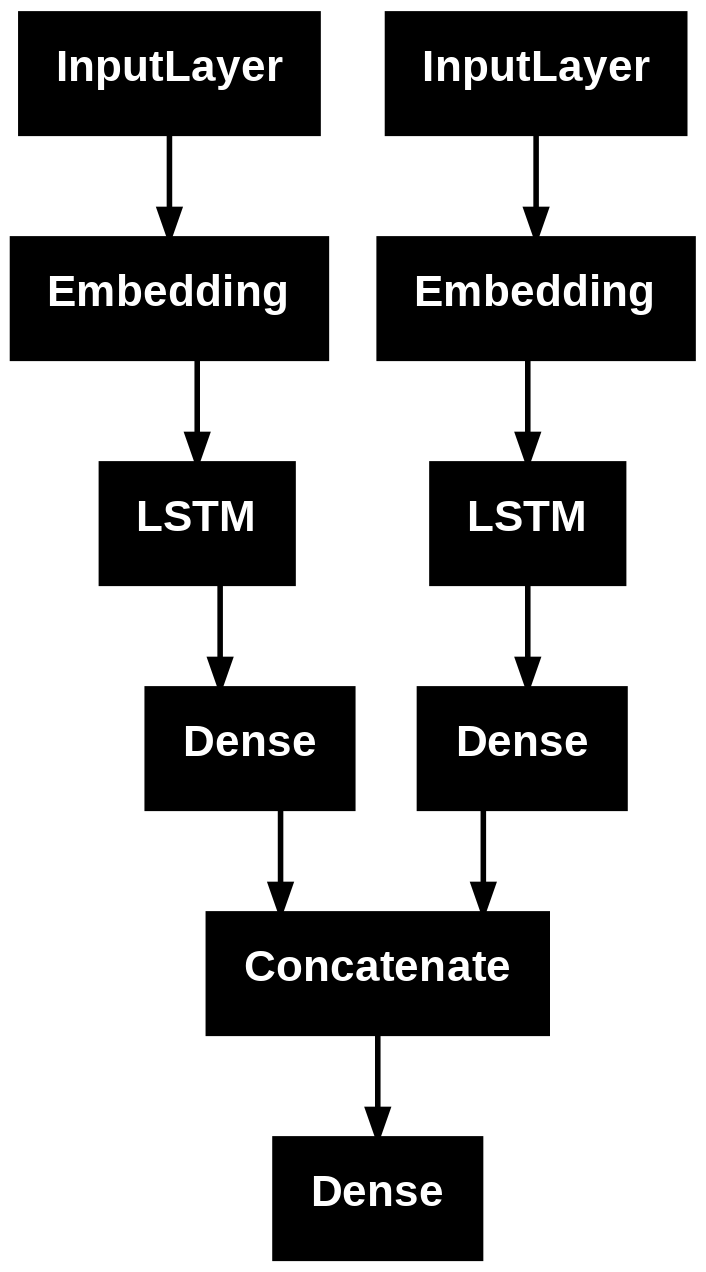

In [42]:
tf.keras.utils.plot_model(fmodel, show_shapes=False, to_file='fmodel1.png')